# 🎙️ Deepfake Voice Detection
### Pakistani Urdu-English Mixed Audio
---

## Step 1 — Libraries Import Karo

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

print('✅ Libraries load ho gayi!')

✅ Libraries load ho gayi!


## Step 2 — Paths Set Karo

In [4]:
REAL_FOLDER = r'E:\DeepfakeProject_Final\processed\real'
FAKE_FOLDER = r'E:\DeepfakeProject_Final\processed\fake'
CSV_PATH    = r'E:\DeepfakeProject_Final\dataset.csv'

# Check karo files hain
real_files = os.listdir(REAL_FOLDER)
fake_files = os.listdir(FAKE_FOLDER)

print(f'🟢 Real files: {len(real_files)}')
print(f'🔴 Fake files: {len(fake_files)}')
print(f'📊 Total     : {len(real_files) + len(fake_files)}')

🟢 Real files: 579
🔴 Fake files: 235
📊 Total     : 814


## Step 3 — MFCC Features Extract Karo

**MFCC kya hai?**
- Audio ko numbers mein convert karta hai
- Model in numbers se seekhta hai
- Real aur Fake voice ke numbers alag hote hain

In [5]:
def extract_mfcc(file_path, n_mfcc=40):
    """
    Ek audio file se MFCC features nikalo
    Output: 40 numbers jo audio ka pattern describe karte hain
    """
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        # Mean lo taake fixed size mile
        return np.mean(mfcc, axis=1)
    except Exception as e:
        print(f'❌ Error: {file_path} → {e}')
        return None

print('✅ Feature extraction function ready!')

✅ Feature extraction function ready!


In [6]:
# Saari files process karo — thoda time lagega!
X = []  # Features
y = []  # Labels (0=real, 1=fake)

print('🟢 Real audio processing...')
for fname in real_files:
    fpath = os.path.join(REAL_FOLDER, fname)
    features = extract_mfcc(fpath)
    if features is not None:
        X.append(features)
        y.append(0)  # 0 = real

print(f'   ✅ Real features extracted: {len([i for i in y if i==0])}')

print('🔴 Fake audio processing...')
for fname in fake_files:
    fpath = os.path.join(FAKE_FOLDER, fname)
    features = extract_mfcc(fpath)
    if features is not None:
        X.append(features)
        y.append(1)  # 1 = fake

print(f'   ✅ Fake features extracted: {len([i for i in y if i==1])}')

X = np.array(X)
y = np.array(y)

print(f'\n📊 Dataset shape: {X.shape}')
print('✅ Features ready!')

🟢 Real audio processing...
   ✅ Real features extracted: 579
🔴 Fake audio processing...
   ✅ Fake features extracted: 235

📊 Dataset shape: (814, 40)
✅ Features ready!


## Step 4 — Train/Test Split Karo

**80% training** — model seekhega in se

**20% testing** — model in pe test hoga

In [7]:
# Split karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # real/fake ratio same rakho
)

# Normalize karo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'📚 Training samples : {len(X_train)}')
print(f'🧪 Testing samples  : {len(X_test)}')
print('✅ Split complete!')

📚 Training samples : 651
🧪 Testing samples  : 163
✅ Split complete!


## Step 5 — Model Train Karo

**Random Forest** use kar rahe hain — kyun?
- Fast hai
- Chhote dataset pe bhi acha kaam karta hai
- Samajhna aasan hai

In [8]:
# Model banao aur train karo
model = RandomForestClassifier(
    n_estimators=100,  # 100 trees
    random_state=42
)

print('🚀 Training shuru...')
model.fit(X_train, y_train)
print('✅ Training complete!')

🚀 Training shuru...
✅ Training complete!


## Step 6 — Results Dekho

In [9]:
# Predictions
y_pred = model.predict(X_test)

# Report
print('=' * 45)
print('         MODEL RESULTS')
print('=' * 45)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

         MODEL RESULTS
              precision    recall  f1-score   support

        Real       0.94      0.97      0.96       116
        Fake       0.93      0.85      0.89        47

    accuracy                           0.94       163
   macro avg       0.94      0.91      0.92       163
weighted avg       0.94      0.94      0.94       163



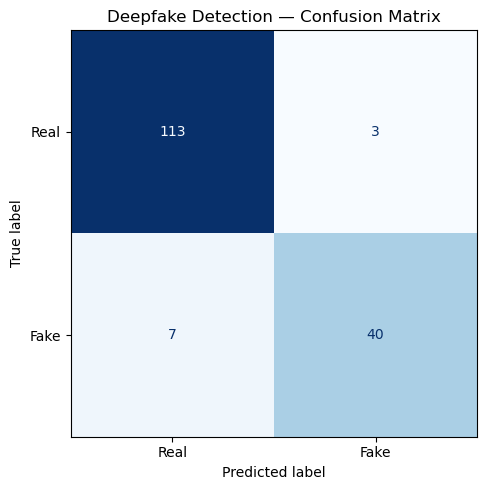

In [10]:
# Confusion Matrix — visual dekho
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Deepfake Detection — Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 7 — Nai Audio Test Karo

Apni koi bhi audio file do — model batayega Real hai ya Fake!

In [15]:
def predict_audio(file_path):
    """
    Koi bhi audio file do — Real ya Fake batayega!
    """
    features = extract_mfcc(file_path)
    if features is None:
        print('❌ File load nahi hui!')
        return
    
    features_scaled = scaler.transform([features])
    prediction      = model.predict(features_scaled)[0]
    confidence      = model.predict_proba(features_scaled)[0]
    
    label = '🔴 FAKE (AI Generated)' if prediction == 1 else '🟢 REAL (Human Voice)'
    conf  = confidence[prediction] * 100
    
    print(f'File     : {os.path.basename(file_path)}')
    print(f'Result   : {label}')
    print(f'Confidence: {conf:.1f}%')

# ← Yahan apni audio file ka path dalo!
predict_audio(r'E:\DeepfakeProject_Final\processed\fake\fake_0015.wav')

File     : fake_0015.wav
Result   : 🔴 FAKE (AI Generated)
Confidence: 93.0%
